Load and inspect the dataset

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "data" / "processed").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
OUTPUT_TABLES = PROJECT_ROOT / "outputs" / "tables"

OUTPUT_TABLES.mkdir(
    parents=True,
    exist_ok=True,
)

input_path = (
    DATA_PROCESSED
    / "landslide_final_event_attributes_with_history.csv"
)

df = pd.read_csv(input_path)

print("Input file:", input_path)
print("Shape:", df.shape)
display(df.head())

Input file: c:\Users\Sadumina Rathnayaka\Desktop\Model\data\processed\landslide_final_event_attributes_with_history.csv
Shape: (479, 66)


,lat,lon,event_date,event_date_start,event_date_end,event_date_count,event_date_status,event_date_raw,event_time_raw,inspection_date,...,soil_cec_0_30,soil_clay_60_100,fold,block_id,label,spatial_match_within_1km,event_observed,static_susceptibility_label,previous_event_count,total_events_at_static_location
0,7.153525,80.789001,2025-11-27,2025-11-27,2025-11-27,1,parsed_single,2025.11.27,NaN,2026-01-25,...,14.52311,28.72892,3,67_72,1,True,1,1,0,1
1,6.993756,80.747054,2025-11-27,2025-11-27,2025-11-27,1,parsed_single,2025.11.27,NaN,2026-06-07,...,15.78921,29.25217,3,65_66,1,True,1,1,0,1
2,6.967445,80.783106,2025-11-27,2025-11-27,2025-11-27,1,parsed_single,2025-11-27 00:00:00,NaN,2026-01-09,...,15.84766,30.96726,4,67_65,1,True,1,1,0,1
3,6.937340,80.799960,2025-11-27,2025-11-27,2025-11-27,1,parsed_single,2025.11.27,NaN,2026-01-31,...,15.00636,30.36993,0,67_64,1,True,1,1,0,1
4,7.078676,80.776533,2025-11-27,2025-11-27,2025-11-27,1,parsed_single,2025-11-27 00:00:00,NaN,2026-01-20,...,15.31111,31.00020,4,66_69,1,True,1,1,0,5


Data Pre Processing: Starting from the input file, we will clean the data and save it to a new CSV file. The cleaned data will be stored in the `data/processed` directory with the name `landslide_final.csv`. And 

Check missing values

In [2]:
missing_summary = (
    df.isna()
    .sum()
    .sort_values(ascending=False)
)

missing_summary = (
    missing_summary[missing_summary > 0]
    .rename("missing_count")
    .to_frame()
)

missing_summary["missing_percentage"] = (
    missing_summary["missing_count"]
    / len(df)
    * 100
)

display(
    missing_summary.round(2)
)

,missing_count,missing_percentage
Count_HR,479,100.00
Reference_,479,100.00
Field,479,100.00
GND,479,100.00
Count_LR,463,96.66
event_time_raw,437,91.23
Revisit,434,90.61
Other_Btns,345,72.03
Count_HR_P,328,68.48
Count_HR_1,292,60.96


In [3]:
all_null_columns = [
    column
    for column in df.columns
    if df[column].isna().all()
]

print("Completely empty columns:")
print(all_null_columns)

Completely empty columns:
['Reference_', 'Field', 'Count_HR', 'GND']


Remove the completely empty columns from the DataFrame

In [4]:
df_clean = df.drop(
    columns=all_null_columns
).copy()

print("Shape after removing completely empty columns:")
print(df_clean.shape)

Shape after removing completely empty columns:
(479, 62)


Convert dates correctly

In [5]:
date_columns = [
    "event_date",
    "event_date_start",
    "event_date_end",
    "inspection_date",
]

for column in date_columns:
    if column in df_clean.columns:
        df_clean[column] = pd.to_datetime(
            df_clean[column],
            errors="coerce",
        )

print(
    df_clean[
        [
            column
            for column in date_columns
            if column in df_clean.columns
        ]
    ].dtypes
)

event_date          datetime64[us]
event_date_start    datetime64[us]
event_date_end      datetime64[us]
inspection_date     datetime64[us]
dtype: object


Check invalid event dates:

In [6]:
if df_clean["event_date"].isna().any():
    raise ValueError(
        "Some rows have invalid or missing event_date values."
    )

Convert numerical columns

In [7]:
numeric_columns = [
    "lat",
    "lon",
    "rain_1d_mm",
    "rain_3d_mm",
    "rain_7d_mm",
    "rain_14d_mm",
    "rain_30d_mm",
    "max_daily_rain_7d_mm",
    "rainfall_days_7d",
    "static_index",
    "distance_to_static_km",
    "soil_clay_0_30",
    "soil_sand_0_30",
    "soil_silt_0_30",
    "soil_oc_0_30",
    "soil_ph_0_30",
    "soil_bd_0_30",
    "soil_awc_0_30",
    "soil_clay_gradient",
    "soil_cec_0_30",
    "soil_clay_60_100",
    "fold",
    "static_susceptibility_label",
    "previous_event_count",
    "total_events_at_static_location",
    "event_observed",
    "label",
]

numeric_columns = [
    column
    for column in numeric_columns
    if column in df_clean.columns
]

for column in numeric_columns:
    df_clean[column] = pd.to_numeric(
        df_clean[column],
        errors="coerce",
    )

Validate essential modelling columns

In [8]:
required_columns = [
    "event_date",
    "lat",
    "lon",
    "rain_1d_mm",
    "rain_3d_mm",
    "rain_7d_mm",
    "rain_14d_mm",
    "rain_30d_mm",
    "max_daily_rain_7d_mm",
    "rainfall_days_7d",
    "distance_to_static_km",
    "static_susceptibility_label",
    "previous_event_count",
    "event_observed",
    "label",
]

missing_required_columns = [
    column
    for column in required_columns
    if column not in df_clean.columns
]

if missing_required_columns:
    raise KeyError(
        "Missing required columns: "
        f"{missing_required_columns}"
    )

Check missing values in important fields


In [9]:
essential_missing = (
    df_clean[required_columns]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

display(
    essential_missing[
        essential_missing > 0
    ]
)

Series([], dtype: int64)

For the current event table, rainfall and soil values should not be missing.

In [10]:
required_numeric_features = [
    "lat",
    "lon",
    "rain_1d_mm",
    "rain_3d_mm",
    "rain_7d_mm",
    "rain_14d_mm",
    "rain_30d_mm",
    "max_daily_rain_7d_mm",
    "rainfall_days_7d",
    "distance_to_static_km",
    "static_susceptibility_label",
    "previous_event_count",
]

missing_feature_rows = (
    df_clean[required_numeric_features]
    .isna()
    .any(axis=1)
)

if missing_feature_rows.any():
    print(
        "Rows with missing required feature values:",
        int(missing_feature_rows.sum()),
    )
    display(
        df_clean.loc[
            missing_feature_rows,
            required_numeric_features,
        ].head()
    )
    raise ValueError(
        "Required modelling attributes contain missing values."
    )

Check duplicate event records

In [11]:
duplicate_key_columns = [
    "lat",
    "lon",
    "event_date",
]

duplicate_count = df_clean.duplicated(
    subset=duplicate_key_columns
).sum()

print(
    "Duplicate location-date records:",
    duplicate_count,
)

if duplicate_count > 0:
    display(
        df_clean.loc[
            df_clean.duplicated(
                subset=duplicate_key_columns,
                keep=False,
            )
        ]
        .sort_values(duplicate_key_columns)
        [
            duplicate_key_columns
            + ["event_key", "label"]
        ]
        .head(20)
    )

Duplicate location-date records: 0


In [12]:
print(
    "Event observed values:",
    sorted(df_clean["event_observed"].dropna().unique()),
)

print(
    "Static susceptibility labels:",
    df_clean[
        "static_susceptibility_label"
    ].value_counts(dropna=False).to_dict(),
)

print(
    "Previous event count summary:"
)

display(
    df_clean[
        [
            "previous_event_count",
            "total_events_at_static_location",
        ]
    ]
    .describe()
    .round(3)
)

Event observed values: [np.int64(1)]
Static susceptibility labels: {1: 297, 0: 182}
Previous event count summary:


,previous_event_count,total_events_at_static_location
count,479.000,479.000
mean,0.063,1.689
std,0.336,1.003
min,0.000,1.000
25%,0.000,1.000
50%,0.000,1.000
75%,0.000,2.000
max,3.000,6.000


In [13]:
if (
    df_clean["previous_event_count"] < 0
).any():
    raise ValueError(
        "previous_event_count cannot be negative."
    )

if (
    df_clean["previous_event_count"]
    > df_clean["total_events_at_static_location"]
).any():
    raise ValueError(
        "Previous event count exceeds total event count."
    )

Create a clean full event table

In [14]:
clean_event_output = (
    DATA_PROCESSED
    / "landslide_final.csv"
)

df_clean.to_csv(
    clean_event_output,
    index=False,
    date_format="%Y-%m-%d",
)

print(
    "Saved cleaned event table:",
    clean_event_output,
)

print(
    "Final shape:",
    df_clean.shape,
)

Saved cleaned event table: c:\Users\Sadumina Rathnayaka\Desktop\Model\data\processed\landslide_final.csv
Final shape: (479, 62)


Start Build Model and Implementation Part 

Load the cleaned positive-event table

In [16]:
from pathlib import Path

import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "data" / "processed").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
OUTPUT_TABLES = PROJECT_ROOT / "outputs" / "tables"

OUTPUT_TABLES.mkdir(
    parents=True,
    exist_ok=True,
)

positive_events = pd.read_csv(
    DATA_PROCESSED
    / "landslide_final.csv"
)

static_df = pd.read_csv(
    DATA_PROCESSED
    / "static_clean_step1.csv"
)

positive_events["event_date"] = pd.to_datetime(
    positive_events["event_date"],
    errors="coerce",
)

print("Positive events:", positive_events.shape)
print("Static grid:", static_df.shape)
print(
    positive_events["event_observed"]
    .value_counts(dropna=False)
)

Positive events: (479, 62)
Static grid: (5437, 17)
event_observed
1    479
Name: count, dtype: int64


Identify static locations already used by events

In [17]:
event_static_indices = set(
    positive_events[
        "static_index"
    ]
    .dropna()
    .astype(int)
)

print(
    "Unique static locations used by events:",
    len(event_static_indices),
)

Unique static locations used by events: 357


Create the control location pool

In [18]:
control_pool = static_df.loc[
    ~static_df.index.isin(event_static_indices)
].copy()

control_pool["static_index"] = control_pool.index

print(
    "Available control locations:",
    len(control_pool),
)

Available control locations: 5080


In [19]:
if len(control_pool) < len(positive_events):
    raise ValueError(
        "There are not enough unused static locations "
        "to create one control per event."
    )

Create one control for each positive event date

In [20]:
random_generator = np.random.default_rng(42)

positive_counts_by_date = (
    positive_events[
        "event_date"
    ]
    .dt.normalize()
    .value_counts()
    .sort_index()
)

control_parts = []

for event_date, positive_count in (
    positive_counts_by_date.items()
):

    available_indices = control_pool.index.to_numpy()

    selected_indices = random_generator.choice(
        available_indices,
        size=int(positive_count),
        replace=False,
    )

    controls_for_date = control_pool.loc[
        selected_indices
    ].copy()

    controls_for_date["event_date"] = event_date
    controls_for_date["event_observed"] = 0
    controls_for_date["label"] = 0

    controls_for_date["control_id"] = (
        "control_"
        + event_date.strftime("%Y%m%d")
        + "_"
        + controls_for_date[
            "static_index"
        ].astype(str)
    )

    control_parts.append(
        controls_for_date
    )

control_events = pd.concat(
    control_parts,
    ignore_index=True,
)

print(
    "Control rows:",
    control_events.shape,
)

print(
    control_events["event_date"]
    .value_counts()
    .sort_index()
)

Control rows: (479, 21)
event_date
2025-11-07      1
2025-11-26     20
2025-11-27    417
2025-11-28     31
2025-11-29      3
2025-12-01      1
2025-12-27      3
2026-08-03      3
Name: count, dtype: int64


Add the original static label separately

In [21]:
control_events = control_events.rename(
    columns={
        "meta_lat": "lat",
        "meta_lon": "lon",
        "label": "dynamic_label",
    }
)

positive_events = positive_events.rename(
    columns={
        "label": "dynamic_label",
    }
)

control_events["static_susceptibility_label"] = (
    control_events["dynamic_label"]
)

Standardise the control columns

In [22]:
soil_features = [
    column
    for column in static_df.columns
    if column.startswith("soil_")
]

control_columns = [
    "static_index",
    "event_date",
    "lat",
    "lon",
    "event_observed",
    "dynamic_label",
    "static_susceptibility_label",
    *soil_features,
    "fold",
    "block_id",
    "control_id",
]

control_columns = [
    column
    for column in control_columns
    if column in control_events.columns
]

control_events = control_events[
    control_columns
].copy()

print(
    control_events[
        [
            "control_id",
            "event_date",
            "lat",
            "lon",
            "event_observed",
            "dynamic_label",
            "static_susceptibility_label",
        ]
    ].head()
)

              control_id event_date       lat        lon  event_observed  \
0   control_20251107_546 2025-11-07  6.929191  80.554960               0   
1  control_20251126_2941 2025-11-26  7.106992  80.714616               0   
2  control_20251126_3608 2025-11-26  6.907319  80.758420               0   
3  control_20251126_4586 2025-11-26  6.798896  80.517692               0   
4  control_20251126_2544 2025-11-26  6.772360  80.708516               0   

   dynamic_label  static_susceptibility_label  
0              0                            0  
1              0                            0  
2              0                            0  
3              0                            0  
4              0                            0  


Check the positive and control label structure

In [23]:
print(
    "Positive dynamic labels:"
)

print(
    positive_events[
        "dynamic_label"
    ]
    .value_counts(dropna=False)
)

print(
    "\nControl dynamic labels:"
)

print(
    control_events[
        "dynamic_label"
    ]
    .value_counts(dropna=False)
)

Positive dynamic labels:
dynamic_label
1    479
Name: count, dtype: int64

Control dynamic labels:
dynamic_label
0    479
Name: count, dtype: int64


Check spatial distributions

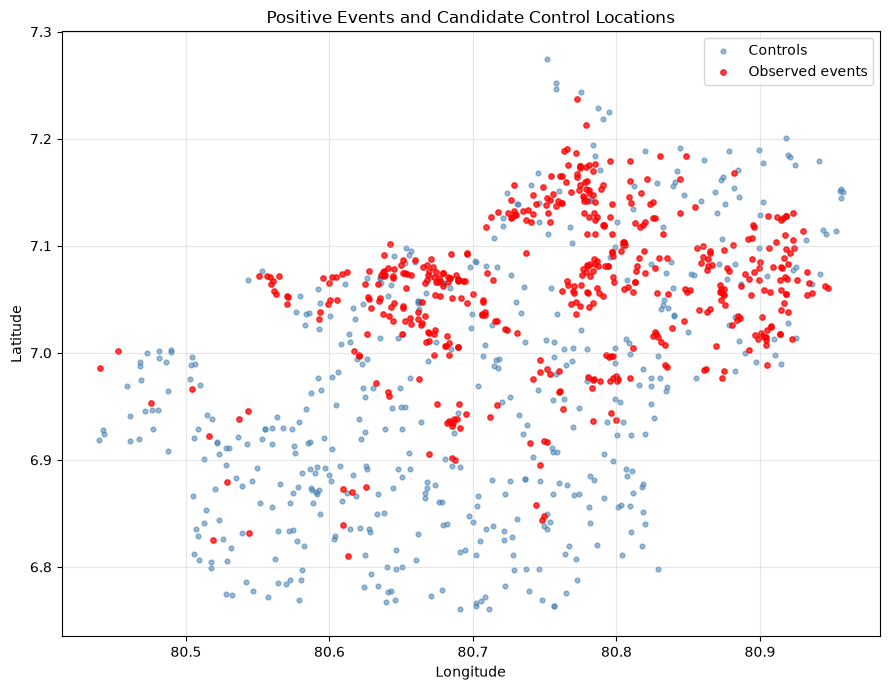

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 7))

plt.scatter(
    control_events["lon"],
    control_events["lat"],
    s=12,
    alpha=0.55,
    label="Controls",
    color="steelblue",
)

plt.scatter(
    positive_events["lon"],
    positive_events["lat"],
    s=15,
    alpha=0.75,
    label="Observed events",
    color="red",
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(
    "Positive Events and Candidate Control Locations"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
control_output = (
    DATA_PROCESSED
    / "landslide_control_locations_same_event_dates.csv"
)

control_events.to_csv(
    control_output,
    index=False,
    date_format="%Y-%m-%d",
)

print(
    "Saved control table:",
    control_output,
)

Saved control table: c:\Users\Sadumina Rathnayaka\Desktop\Model\data\processed\landslide_control_locations_same_event_dates.csv


combine datasets rainfall+Soil and Landlside his data

In [26]:
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "data" / "processed").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

control_events = pd.read_csv(
    DATA_PROCESSED
    / "landslide_control_locations_same_event_dates.csv"
)

control_events["event_date"] = pd.to_datetime(
    control_events["event_date"],
    errors="coerce",
)

print("Control rows:", control_events.shape)
print(
    control_events[
        [
            "control_id",
            "static_index",
            "event_date",
            "lat",
            "lon",
            "dynamic_label",
        ]
    ].head()
)

Control rows: (479, 20)
              control_id  static_index event_date       lat        lon  \
0   control_20251107_546           546 2025-11-07  6.929191  80.554960   
1  control_20251126_2941          2941 2025-11-26  7.106992  80.714616   
2  control_20251126_3608          3608 2025-11-26  6.907319  80.758420   
3  control_20251126_4586          4586 2025-11-26  6.798896  80.517692   
4  control_20251126_2544          2544 2025-11-26  6.772360  80.708516   

   dynamic_label  
0              0  
1              0  
2              0  
3              0  
4              0  


In [27]:
required_control_columns = [
    "control_id",
    "static_index",
    "event_date",
    "lat",
    "lon",
    "dynamic_label",
]

missing_columns = [
    column
    for column in required_control_columns
    if column not in control_events.columns
]

if missing_columns:
    raise KeyError(
        f"Missing control columns: {missing_columns}"
    )

if control_events[
    ["event_date", "lat", "lon"]
].isna().any().any():
    raise ValueError(
        "Controls contain missing dates or coordinates."
    )

if not control_events["dynamic_label"].eq(0).all():
    raise ValueError(
        "All control rows must have dynamic_label = 0."
    )

Extract rainfall for each control

In [28]:
import time
import requests
import numpy as np

RAIN_FEATURES = [
    "rain_1d_mm",
    "rain_3d_mm",
    "rain_7d_mm",
    "rain_14d_mm",
    "rain_30d_mm",
    "max_daily_rain_7d_mm",
    "rainfall_days_7d",
]

POWER_URL = (
    "https://power.larc.nasa.gov/api/temporal/daily/point"
)

def extract_power_features(
    latitude,
    longitude,
    event_date,
    timeout=60,
):
    """
    Extract rainfall features from the 30 days before
    through the event date.
    """

    event_date = pd.Timestamp(event_date)

    start_date = (
        event_date - pd.Timedelta(days=29)
    ).strftime("%Y%m%d")

    end_date = event_date.strftime("%Y%m%d")

    params = {
        "parameters": "PRECTOTCORR",
        "community": "AG",
        "longitude": float(longitude),
        "latitude": float(latitude),
        "start": start_date,
        "end": end_date,
        "format": "JSON",
    }

    response = requests.get(
        POWER_URL,
        params=params,
        timeout=timeout,
    )

    response.raise_for_status()

    payload = response.json()

    try:
        values = payload["properties"]["parameter"][
            "PRECTOTCORR"
        ]
    except KeyError as error:
        raise ValueError(
            "NASA POWER response did not contain "
            "PRECTOTCORR values."
        ) from error

    rainfall = pd.Series(
        values,
        dtype="float64",
    )

    rainfall = rainfall.replace(
        [-999, -999.0],
        np.nan,
    ).dropna()

    if rainfall.empty:
        raise ValueError(
            "No valid rainfall values were returned."
        )

    return {
        "rain_1d_mm": rainfall.iloc[-1],
        "rain_3d_mm": rainfall.tail(3).sum(),
        "rain_7d_mm": rainfall.tail(7).sum(),
        "rain_14d_mm": rainfall.tail(14).sum(),
        "rain_30d_mm": rainfall.tail(30).sum(),
        "max_daily_rain_7d_mm": rainfall.tail(7).max(),
        "rainfall_days_7d": (
            rainfall.tail(7) > 0
        ).sum(),
    }

Run extraction for each control

In [29]:
control_rainfall_rows = []

for row_number, row in control_events.iterrows():

    try:
        rainfall_features = extract_power_features(
            latitude=row["lat"],
            longitude=row["lon"],
            event_date=row["event_date"],
        )

        rainfall_features["control_id"] = (
            row["control_id"]
        )

        rainfall_features["rainfall_status"] = "ok"

    except Exception as error:
        print(
            f"Rainfall extraction failed for row "
            f"{row_number}: {error}"
        )

        rainfall_features = {
            "control_id": row["control_id"],
            "rain_1d_mm": np.nan,
            "rain_3d_mm": np.nan,
            "rain_7d_mm": np.nan,
            "rain_14d_mm": np.nan,
            "rain_30d_mm": np.nan,
            "max_daily_rain_7d_mm": np.nan,
            "rainfall_days_7d": np.nan,
            "rainfall_status": "failed",
        }

    control_rainfall_rows.append(
        rainfall_features
    )

    # Avoid making requests too quickly.
    time.sleep(0.15)

control_rainfall = pd.DataFrame(
    control_rainfall_rows
)

print(
    "Extracted rainfall rows:",
    control_rainfall.shape,
)

display(
    control_rainfall.head()
)

Extracted rainfall rows: (479, 9)


,rain_1d_mm,rain_3d_mm,rain_7d_mm,rain_14d_mm,rain_30d_mm,max_daily_rain_7d_mm,rainfall_days_7d,control_id,rainfall_status
0,5.69,15.56,19.80,38.70,316.77,7.71,7,control_20251107_546,ok
1,82.58,168.03,233.01,381.89,441.98,82.58,7,control_20251126_2941,ok
2,82.58,168.03,233.01,381.89,441.98,82.58,7,control_20251126_3608,ok
3,82.58,168.03,233.01,381.89,441.98,82.58,7,control_20251126_4586,ok
4,82.58,168.03,233.01,381.89,441.98,82.58,7,control_20251126_2544,ok


Validate the extraction

In [30]:
print(
    control_rainfall[
        "rainfall_status"
    ].value_counts(dropna=False)
)

missing_rainfall = (
    control_rainfall[RAIN_FEATURES]
    .isna()
    .any(axis=1)
)

print(
    "Rows with missing rainfall features:",
    int(missing_rainfall.sum()),
)

rainfall_status
ok    479
Name: count, dtype: int64
Rows with missing rainfall features: 0


Merge rainfall into the controls

In [31]:
control_with_rainfall = control_events.merge(
    control_rainfall,
    on="control_id",
    how="left",
    validate="one_to_one",
)

print(
    "Control table with rainfall:",
    control_with_rainfall.shape,
)

display(
    control_with_rainfall[
        [
            "control_id",
            "event_date",
            "lat",
            "lon",
            "rain_1d_mm",
            "rain_3d_mm",
            "rain_7d_mm",
            "rain_14d_mm",
            "dynamic_label",
        ]
    ].head()
)

Control table with rainfall: (479, 28)


,control_id,event_date,lat,lon,rain_1d_mm,rain_3d_mm,rain_7d_mm,rain_14d_mm,dynamic_label
0,control_20251107_546,2025-11-07,6.929191,80.554960,5.69,15.56,19.80,38.70,0
1,control_20251126_2941,2025-11-26,7.106992,80.714616,82.58,168.03,233.01,381.89,0
2,control_20251126_3608,2025-11-26,6.907319,80.758420,82.58,168.03,233.01,381.89,0
3,control_20251126_4586,2025-11-26,6.798896,80.517692,82.58,168.03,233.01,381.89,0
4,control_20251126_2544,2025-11-26,6.772360,80.708516,82.58,168.03,233.01,381.89,0


In [32]:
if control_with_rainfall[RAIN_FEATURES].isna().any().any():
    raise ValueError(
        "Control rainfall features still contain missing values."
    )

if not control_with_rainfall[
    "dynamic_label"
].eq(0).all():
    raise ValueError(
        "Control labels changed unexpectedly."
    )

Save the control rainfall table to a CSV file.

In [33]:
control_output = (
    DATA_PROCESSED
    / "landslide_control_features_with_rainfall.csv"
)

control_with_rainfall.to_csv(
    control_output,
    index=False,
    date_format="%Y-%m-%d",
)

print(
    "Saved:",
    control_output,
)

Saved: c:\Users\Sadumina Rathnayaka\Desktop\Model\data\processed\landslide_control_features_with_rainfall.csv


Load both tables

In [35]:
from pathlib import Path

import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()

if not (
    PROJECT_ROOT / "data" / "processed"
).is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PROCESSED = (
    PROJECT_ROOT / "data" / "processed"
)

OUTPUT_TABLES = (
    PROJECT_ROOT / "outputs" / "tables"
)

OUTPUT_TABLES.mkdir(
    parents=True,
    exist_ok=True,
)

positive_events = df_clean.copy()

positive_events["event_date"] = pd.to_datetime(
    positive_events["event_date"],
    errors="coerce",
)

if "dynamic_label" not in positive_events.columns:
    positive_events["dynamic_label"] = positive_events["label"]

positive_events.to_csv(
    DATA_PROCESSED / "landslide_positive_event_features.csv",
    index=False,
    date_format="%Y-%m-%d",
)

print(
    "Saved positive table:",
    DATA_PROCESSED / "landslide_positive_event_features.csv",
)

control_events = pd.read_csv(
    DATA_PROCESSED
    / "landslide_control_features_with_rainfall.csv"
)

print(
    "Positive table:",
    positive_events.shape,
)

print(
    "Control table:",
    control_events.shape,
)

Saved positive table: c:\Users\Sadumina Rathnayaka\Desktop\Model\data\processed\landslide_positive_event_features.csv
Positive table: (479, 63)
Control table: (479, 28)


Standardise dates and labels

In [36]:
positive_events["event_date"] = pd.to_datetime(
    positive_events["event_date"],
    errors="coerce",
)

control_events["event_date"] = pd.to_datetime(
    control_events["event_date"],
    errors="coerce",
)

# Use dynamic_label as the target for the rainfall model.
positive_events["dynamic_label"] = 1
control_events["dynamic_label"] = 0

In [37]:
print(
    "Positive labels:",
    positive_events["dynamic_label"]
    .value_counts(dropna=False)
    .to_dict(),
)

print(
    "Control labels:",
    control_events["dynamic_label"]
    .value_counts(dropna=False)
    .to_dict(),
)

Positive labels: {1: 479}
Control labels: {0: 479}


 Standardise coordinate names

In [38]:
coordinate_renames = {
    "latitude": "lat",
    "longitude": "lon",
}

positive_events = positive_events.rename(
    columns=coordinate_renames
)

control_events = control_events.rename(
    columns=coordinate_renames
)

In [39]:
for name, frame in [
    ("positive", positive_events),
    ("control", control_events),
]:
    required = [
        "lat",
        "lon",
        "event_date",
        "dynamic_label",
    ]

    missing = [
        column
        for column in required
        if column not in frame.columns
    ]

    if missing:
        raise KeyError(
            f"{name} table is missing: {missing}"
        )

Define the model features

In [40]:
soil_features = [
    column
    for column in positive_events.columns
    if column.startswith("soil_")
]

rainfall_features = [
    "rain_1d_mm",
    "rain_3d_mm",
    "rain_7d_mm",
    "rain_14d_mm",
    "rain_30d_mm",
    "max_daily_rain_7d_mm",
    "rainfall_days_7d",
]

history_features = [
    "static_susceptibility_label",
]

location_features = [
    "lat",
    "lon",
]

identifier_features = [
    "event_date",
    "static_index",
    "distance_to_static_km",
    "fold",
    "block_id",
    "event_key",
    "control_id",
    "dynamic_label",
]

In [41]:
model_columns = (
    location_features
    + soil_features
    + rainfall_features
    + history_features
)

metadata_columns = [
    column
    for column in identifier_features
    if (
        column in positive_events.columns
        or column in control_events.columns
    )
]

common_columns = [
    column
    for column in model_columns
    if (
        column in positive_events.columns
        and column in control_events.columns
    )
]

print("Common model columns:")
print(common_columns)

Common model columns:
['lat', 'lon', 'soil_clay_0_30', 'soil_sand_0_30', 'soil_silt_0_30', 'soil_oc_0_30', 'soil_ph_0_30', 'soil_bd_0_30', 'soil_awc_0_30', 'soil_clay_gradient', 'soil_cec_0_30', 'soil_clay_60_100', 'rain_1d_mm', 'rain_3d_mm', 'rain_7d_mm', 'rain_14d_mm', 'rain_30d_mm', 'max_daily_rain_7d_mm', 'rainfall_days_7d', 'static_susceptibility_label']


In [42]:
missing_model_columns = [
    column
    for column in model_columns
    if (
        column not in positive_events.columns
        or column not in control_events.columns
    )
]

if missing_model_columns:
    raise KeyError(
        "Missing model columns: "
        f"{missing_model_columns}"
    )

Select and combine the two tables

In [43]:
positive_for_ml = positive_events[
    common_columns + [
        column
        for column in metadata_columns
        if column in positive_events.columns
    ]
].copy()

control_for_ml = control_events[
    common_columns + [
        column
        for column in metadata_columns
        if column in control_events.columns
    ]
].copy()

In [44]:
all_ml_columns = sorted(
    set(positive_for_ml.columns)
    | set(control_for_ml.columns)
)

positive_for_ml = positive_for_ml.reindex(
    columns=all_ml_columns
)

control_for_ml = control_for_ml.reindex(
    columns=all_ml_columns
)

dynamic_dataset = pd.concat(
    [
        positive_for_ml,
        control_for_ml,
    ],
    ignore_index=True,
)

Add a unique row identifier

In [45]:
dynamic_dataset.insert(
    0,
    "sample_id",
    [
        f"sample_{index:05d}"
        for index in range(
            len(dynamic_dataset)
        )
    ],
)

Validate the combined dataset

In [46]:
print(
    "Combined dynamic dataset:",
    dynamic_dataset.shape,
)

print(
    "Target distribution:"
)

display(
    dynamic_dataset[
        "dynamic_label"
    ]
    .value_counts(dropna=False)
    .rename_axis("dynamic_label")
    .reset_index(name="count")
)

Combined dynamic dataset: (958, 29)
Target distribution:


,dynamic_label,count
0,1,479
1,0,479


In [47]:
if (
    dynamic_dataset[
        "dynamic_label"
    ].nunique()
    != 2
):
    raise ValueError(
        "The dynamic dataset must contain "
        "both label 0 and label 1."
    )

In [48]:
essential_columns = (
    common_columns
    + ["dynamic_label"]
)

missing_summary = (
    dynamic_dataset[
        essential_columns
    ]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

display(
    missing_summary[
        missing_summary > 0
    ]
)

Series([], dtype: int64)

Stop if required model values are missing

In [49]:
if (
    dynamic_dataset[
        essential_columns
    ]
    .isna()
    .any()
    .any()
):
    raise ValueError(
        "The dynamic modelling columns "
        "contain missing values."
    )

Check for duplicate observations

In [50]:
duplicate_keys = [
    "lat",
    "lon",
    "event_date",
    "dynamic_label",
]

duplicate_count = dynamic_dataset.duplicated(
    subset=duplicate_keys
).sum()

print(
    "Duplicate location-date-label rows:",
    duplicate_count,
)

Duplicate location-date-label rows: 0


In [51]:
if duplicate_count > 0:
    display(
        dynamic_dataset.loc[
            dynamic_dataset.duplicated(
                subset=duplicate_keys,
                keep=False,
            )
        ]
        .sort_values(duplicate_keys)
        .head(20)
    )

Compare positive and control rainfall

In [52]:
rainfall_summary = (
    dynamic_dataset
    .groupby("dynamic_label")[
        rainfall_features
    ]
    .agg(["mean", "median", "min", "max"])
    .round(2)
)

display(rainfall_summary)

rain_1d_mm                       rain_3d_mm                \
                    mean  median   min     max       mean  median   min   
dynamic_label                                                             
0                 160.50  174.86  0.13  197.46     279.57  286.79  1.68   
1                 160.21  174.86  0.13  197.46     279.46  286.79  1.68   

                      rain_7d_mm          ... rain_30d_mm          \
                  max       mean  median  ...         min     max   
dynamic_label                             ...                       
0              338.22     393.58  402.72  ...       83.42  685.37   
1              322.04     393.83  402.72  ...       97.50  685.69   

              max_daily_rain_7d_mm                       rainfall_days_7d  \
                              mean  median   min     max             mean   
dynamic_label                                                               
0                           169.18  174.86  4.59  197.46             7.00   
1                           168.81  174.86  4.59  197.46             6.96   

                                
              median  min  max  
dynamic_label                   
0                7.0  7.0  7.0  
1                7.0  3.0  7.0  

[2 rows x 28 columns]

Plot the main rainfall features

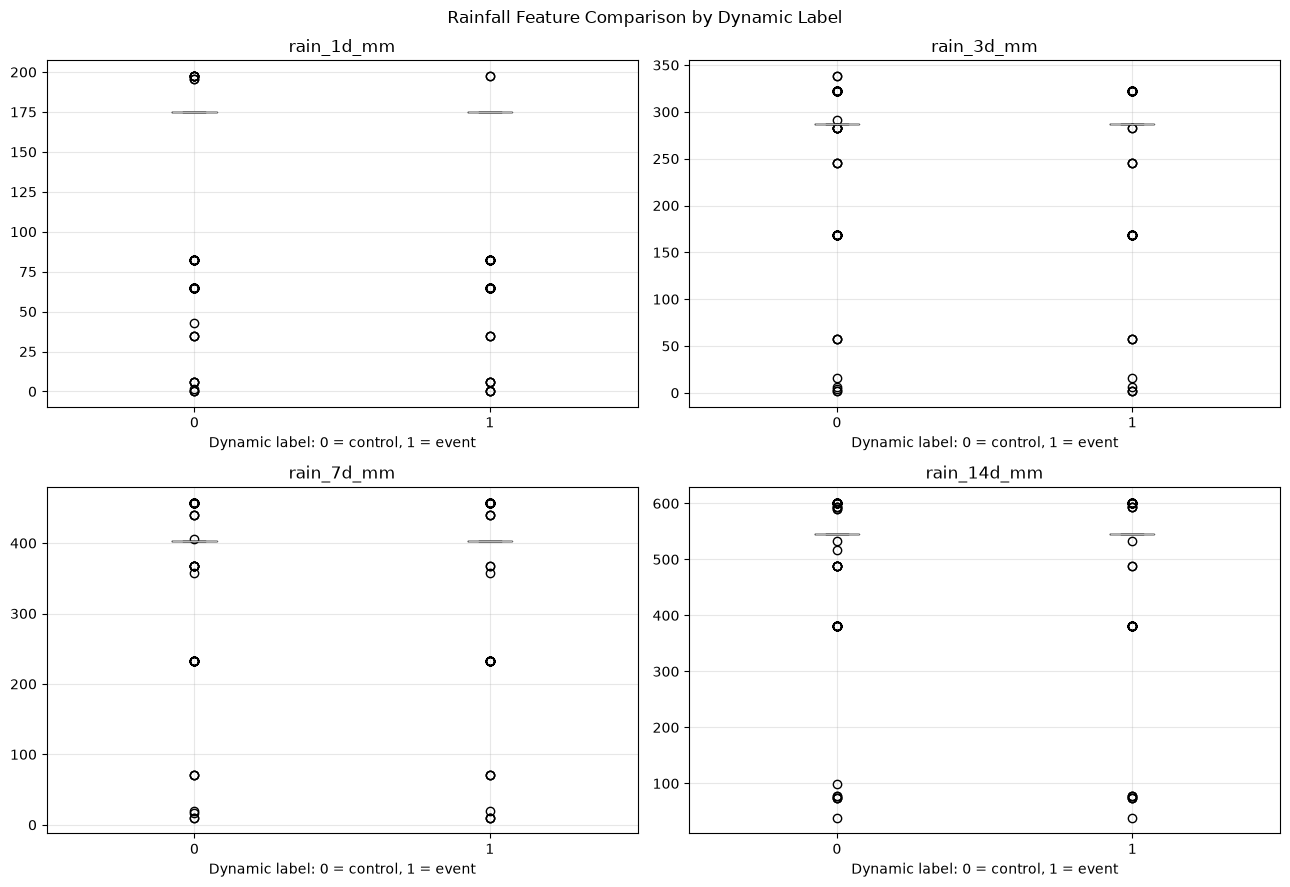

In [53]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    2,
    2,
    figsize=(13, 9),
)

for axis, feature in zip(
    axes.ravel(),
    [
        "rain_1d_mm",
        "rain_3d_mm",
        "rain_7d_mm",
        "rain_14d_mm",
    ],
):
    dynamic_dataset.boxplot(
        column=feature,
        by="dynamic_label",
        ax=axis,
    )

    axis.set_title(feature)
    axis.set_xlabel(
        "Dynamic label: 0 = control, 1 = event"
    )
    axis.grid(alpha=0.3)

plt.suptitle(
    "Rainfall Feature Comparison by Dynamic Label"
)

plt.tight_layout()
plt.show()

Save the combined dataset

In [54]:
dynamic_output = (
    DATA_PROCESSED
    / "landslide_dynamic_ml_dataset.csv"
)

dynamic_dataset.to_csv(
    dynamic_output,
    index=False,
    date_format="%Y-%m-%d",
)

print(
    "Saved dynamic ML dataset:",
    dynamic_output,
)

Saved dynamic ML dataset: c:\Users\Sadumina Rathnayaka\Desktop\Model\data\processed\landslide_dynamic_ml_dataset.csv


Also save the selected feature list

In [55]:
feature_manifest = pd.DataFrame({
    "feature": common_columns,
    "feature_group": [
        (
            "soil"
            if column.startswith("soil_")
            else "rainfall"
            if column in rainfall_features
            else "history_or_location"
        )
        for column in common_columns
    ],
})

feature_manifest.to_csv(
    OUTPUT_TABLES
    / "dynamic_model_feature_manifest.csv",
    index=False,
)

display(feature_manifest)

,feature,feature_group
0,lat,history_or_location
1,lon,history_or_location
2,soil_clay_0_30,soil
3,soil_sand_0_30,soil
4,soil_silt_0_30,soil
5,soil_oc_0_30,soil
6,soil_ph_0_30,soil
7,soil_bd_0_30,soil
8,soil_awc_0_30,soil
9,soil_clay_gradient,soil


One final preprocessing check

In [57]:
print(dynamic_dataset.shape)

print(
    dynamic_dataset[
        "dynamic_label"
    ]
    .value_counts(dropna=False)
)

print(
    dynamic_dataset[
        common_columns
    ]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print(
    "Duplicate location-date-label rows:",
    dynamic_dataset.duplicated(
        subset=[
            "lat",
            "lon",
            "event_date",
            "dynamic_label",
        ]
    ).sum()
)

(958, 29)
dynamic_label
1    479
0    479
Name: count, dtype: int64
lat                            0
lon                            0
soil_clay_0_30                 0
soil_sand_0_30                 0
soil_silt_0_30                 0
soil_oc_0_30                   0
soil_ph_0_30                   0
soil_bd_0_30                   0
soil_awc_0_30                  0
soil_clay_gradient             0
soil_cec_0_30                  0
soil_clay_60_100               0
rain_1d_mm                     0
rain_3d_mm                     0
rain_7d_mm                     0
rain_14d_mm                    0
rain_30d_mm                    0
max_daily_rain_7d_mm           0
rainfall_days_7d               0
static_susceptibility_label    0
dtype: int64
Duplicate location-date-label rows: 0


End of the Data Pre Processing For Now 

Load and define features

In [60]:
from pathlib import Path

import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()

if not (
    PROJECT_ROOT / "data" / "processed"
).is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PROCESSED = (
    PROJECT_ROOT / "data" / "processed"
)

OUTPUT_TABLES = (
    PROJECT_ROOT / "outputs" / "tables"
)

OUTPUT_FIGURES = (
    PROJECT_ROOT / "outputs" / "figures"
)

OUTPUT_TABLES.mkdir(
    parents=True,
    exist_ok=True,
)

OUTPUT_FIGURES.mkdir(
    parents=True,
    exist_ok=True,
)

dynamic_df = pd.read_csv(
    DATA_PROCESSED
    / "landslide_dynamic_ml_dataset.csv"
)

dynamic_df["event_date"] = pd.to_datetime(
    dynamic_df["event_date"],
    errors="coerce",
)

print("Dataset shape:", dynamic_df.shape)
print(
    dynamic_df[
        "dynamic_label"
    ]
    .value_counts()
)

Dataset shape: (958, 29)
dynamic_label
1    479
0    479
Name: count, dtype: int64


Define feature groups

In [61]:
SOIL_FEATURES = [
    column
    for column in dynamic_df.columns
    if column.startswith("soil_")
]

RAINFALL_FEATURES = [
    "rain_1d_mm",
    "rain_3d_mm",
    "rain_7d_mm",
    "rain_14d_mm",
    "rain_30d_mm",
    "max_daily_rain_7d_mm",
    "rainfall_days_7d",
]

LOCATION_FEATURES = [
    "lat",
    "lon",
]

HISTORY_FEATURES = [
    "static_susceptibility_label",
]

MODEL_FEATURES = (
    SOIL_FEATURES
    + RAINFALL_FEATURES
    + LOCATION_FEATURES
    + HISTORY_FEATURES
)

TARGET = "dynamic_label"

missing_features = [
    column
    for column in MODEL_FEATURES + [TARGET]
    if column not in dynamic_df.columns
]

if missing_features:
    raise KeyError(
        f"Missing required columns: {missing_features}"
    )

print("Soil features:", len(SOIL_FEATURES))
print("Rainfall features:", len(RAINFALL_FEATURES))
print("Location features:", len(LOCATION_FEATURES))
print("History features:", len(HISTORY_FEATURES))
print("Total model features:", len(MODEL_FEATURES))

Soil features: 10
Rainfall features: 7
Location features: 2
History features: 1
Total model features: 20


Validate the modelling table

In [62]:
if dynamic_df[MODEL_FEATURES].isna().any().any():
    missing_summary = (
        dynamic_df[MODEL_FEATURES]
        .isna()
        .sum()
    )

    display(
        missing_summary[
            missing_summary > 0
        ]
    )

    raise ValueError(
        "Missing values are present in model features."
    )

if dynamic_df[TARGET].nunique() != 2:
    raise ValueError(
        "The target must contain both classes 0 and 1."
    )

print("No missing model features.")
print("Target classes are valid.")

No missing model features.
Target classes are valid.


Create a spatially grouped split

In [63]:
available_folds = sorted(
    dynamic_df["fold"]
    .dropna()
    .unique()
)

print("Available spatial folds:", available_folds)
print(
    dynamic_df["fold"]
    .value_counts()
    .sort_index()
)

Available spatial folds: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
fold
0    162
1    251
2    145
3    178
4    222
Name: count, dtype: int64


In [64]:
TEST_FOLD = available_folds[-1]

train_mask = (
    dynamic_df["fold"] != TEST_FOLD
)

test_mask = (
    dynamic_df["fold"] == TEST_FOLD
)

X_train = dynamic_df.loc[
    train_mask,
    MODEL_FEATURES,
]

X_test = dynamic_df.loc[
    test_mask,
    MODEL_FEATURES,
]

y_train = dynamic_df.loc[
    train_mask,
    TARGET,
].to_numpy()

y_test = dynamic_df.loc[
    test_mask,
    TARGET,
].to_numpy()

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Test fold:", TEST_FOLD)
print("Training labels:", np.bincount(y_train))
print("Test labels:", np.bincount(y_test))

Training rows: 736
Test rows: 222
Test fold: 4
Training labels: [379 357]
Test labels: [100 122]


Check that both classes exist in both partitions:

In [65]:
if len(np.unique(y_train)) != 2:
    raise ValueError(
        "Training split does not contain both classes."
    )

if len(np.unique(y_test)) != 2:
    raise ValueError(
        "Test split does not contain both classes."
    )

Define the three models

In [66]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

SEED = 42

MODELS = {
    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=SEED,
        ),
    ),

    "XGBoost": XGBClassifier(
        n_estimators=250,
        max_depth=3,
        learning_rate=0.04,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=10,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=SEED,
        n_jobs=2,
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=250,
        max_depth=3,
        num_leaves=8,
        learning_rate=0.04,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_samples=40,
        reg_lambda=5,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=2,
        verbosity=-1,
    ),
}

Train and evaluate the spatial test fold

In [67]:
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)

model_results = []
model_predictions = {}

for model_name, model in MODELS.items():

    print(
        f"Training {model_name}..."
    )

    model.fit(
        X_train,
        y_train,
    )

    probabilities = model.predict_proba(
        X_test
    )[:, 1]

    model_predictions[model_name] = probabilities

    # Use 0.50 only as an initial comparison threshold.
    predictions = (
        probabilities >= 0.50
    ).astype(int)

    model_results.append({
        "model": model_name,
        "test_fold": TEST_FOLD,
        "n_test": len(y_test),
        "accuracy": accuracy_score(
            y_test,
            predictions,
        ),
        "roc_auc": roc_auc_score(
            y_test,
            probabilities,
        ),
        "average_precision": average_precision_score(
            y_test,
            probabilities,
        ),
        "precision": precision_score(
            y_test,
            predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            y_test,
            predictions,
            zero_division=0,
        ),
        "brier_score": brier_score_loss(
            y_test,
            probabilities,
        ),
    })

baseline_results = (
    pd.DataFrame(model_results)
    .sort_values(
        "average_precision",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    baseline_results.round(4)
)

Training Logistic Regression...
Training XGBoost...
Training LightGBM...


,model,test_fold,n_test,accuracy,roc_auc,average_precision,precision,recall,brier_score
0,LightGBM,4,222,0.9865,0.9980,0.9985,1.0000,0.9754,0.0144
1,XGBoost,4,222,0.9369,0.9843,0.9890,0.9355,0.9508,0.0473
2,Logistic Regression,4,222,0.8423,0.9475,0.9665,0.8321,0.8934,0.0893


 Add F1-score

In [68]:
from sklearn.metrics import f1_score

for row in model_results:
    model_name = row["model"]

    probabilities = model_predictions[
        model_name
    ]

    predictions = (
        probabilities >= 0.50
    ).astype(int)

    row["f1"] = f1_score(
        y_test,
        predictions,
        zero_division=0,
    )

baseline_results = (
    pd.DataFrame(model_results)
    .sort_values(
        "average_precision",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    baseline_results.round(4)
)

,model,test_fold,n_test,accuracy,roc_auc,average_precision,precision,recall,brier_score,f1
0,LightGBM,4,222,0.9865,0.9980,0.9985,1.0000,0.9754,0.0144,0.9876
1,XGBoost,4,222,0.9369,0.9843,0.9890,0.9355,0.9508,0.0473,0.9431
2,Logistic Regression,4,222,0.8423,0.9475,0.9665,0.8321,0.8934,0.0893,0.8617


Save the baseline results

In [69]:
baseline_results.to_csv(
    OUTPUT_TABLES
    / "dynamic_spatial_baseline_results.csv",
    index=False,
)

print(
    "Saved baseline results."
)

Saved baseline results.


Compare training and test performance

In [70]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    brier_score_loss,
)

train_test_rows = []

for model_name, model in MODELS.items():

    train_probability = model.predict_proba(
        X_train
    )[:, 1]

    test_probability = model.predict_proba(
        X_test
    )[:, 1]

    train_prediction = (
        train_probability >= 0.50
    ).astype(int)

    test_prediction = (
        test_probability >= 0.50
    ).astype(int)

    train_test_rows.extend([
        {
            "model": model_name,
            "split": "Train",
            "accuracy": accuracy_score(
                y_train,
                train_prediction,
            ),
            "roc_auc": roc_auc_score(
                y_train,
                train_probability,
            ),
            "average_precision": average_precision_score(
                y_train,
                train_probability,
            ),
            "precision": precision_score(
                y_train,
                train_prediction,
                zero_division=0,
            ),
            "recall": recall_score(
                y_train,
                train_prediction,
                zero_division=0,
            ),
            "f1": f1_score(
                y_train,
                train_prediction,
                zero_division=0,
            ),
            "brier_score": brier_score_loss(
                y_train,
                train_probability,
            ),
        },
        {
            "model": model_name,
            "split": "Spatial test",
            "accuracy": accuracy_score(
                y_test,
                test_prediction,
            ),
            "roc_auc": roc_auc_score(
                y_test,
                test_probability,
            ),
            "average_precision": average_precision_score(
                y_test,
                test_probability,
            ),
            "precision": precision_score(
                y_test,
                test_prediction,
                zero_division=0,
            ),
            "recall": recall_score(
                y_test,
                test_prediction,
                zero_division=0,
            ),
            "f1": f1_score(
                y_test,
                test_prediction,
                zero_division=0,
            ),
            "brier_score": brier_score_loss(
                y_test,
                test_probability,
            ),
        },
    ])

train_test_results = pd.DataFrame(
    train_test_rows
).round(4)

display(train_test_results)

,model,split,accuracy,roc_auc,average_precision,precision,recall,f1,brier_score
0,Logistic Regression,Train,0.8139,0.9155,0.9235,0.8374,0.7647,0.7994,0.1151
1,Logistic Regression,Spatial test,0.8423,0.9475,0.9665,0.8321,0.8934,0.8617,0.0893
2,XGBoost,Train,0.9620,0.9958,0.9959,0.9582,0.9636,0.9609,0.0263
3,XGBoost,Spatial test,0.9369,0.9843,0.9890,0.9355,0.9508,0.9431,0.0473
4,LightGBM,Train,0.9946,0.9998,0.9998,1.0000,0.9888,0.9944,0.0073
5,LightGBM,Spatial test,0.9865,0.9980,0.9985,1.0000,0.9754,0.9876,0.0144


Calculate the overfitting gap:

In [71]:
gap_rows = []

for model_name in MODELS:

    train_row = train_test_results.loc[
        (train_test_results["model"] == model_name)
        & (train_test_results["split"] == "Train")
    ].iloc[0]

    test_row = train_test_results.loc[
        (train_test_results["model"] == model_name)
        & (train_test_results["split"] == "Spatial test")
    ].iloc[0]

    gap_rows.append({
        "model": model_name,
        "accuracy_gap": (
            train_row["accuracy"]
            - test_row["accuracy"]
        ),
        "roc_auc_gap": (
            train_row["roc_auc"]
            - test_row["roc_auc"]
        ),
        "average_precision_gap": (
            train_row["average_precision"]
            - test_row["average_precision"]
        ),
        "f1_gap": (
            train_row["f1"]
            - test_row["f1"]
        ),
    })

overfitting_gaps = pd.DataFrame(
    gap_rows
).round(4)

display(overfitting_gaps)

,model,accuracy_gap,roc_auc_gap,average_precision_gap,f1_gap
0,Logistic Regression,-0.0284,-0.0320,-0.0430,-0.0623
1,XGBoost,0.0251,0.0115,0.0069,0.0178
2,LightGBM,0.0081,0.0018,0.0013,0.0068


Retrain without static_susceptibility_label

In [73]:
MODEL_FEATURES_NO_STATIC_LABEL = [
    feature
    for feature in MODEL_FEATURES
    if feature != "static_susceptibility_label"
]

X_train_no_static_label = dynamic_df.loc[
    train_mask,
    MODEL_FEATURES_NO_STATIC_LABEL,
]

X_test_no_static_label = dynamic_df.loc[
    test_mask,
    MODEL_FEATURES_NO_STATIC_LABEL,
]

ablation_results = []

for model_name, model in MODELS.items():

    model.fit(
        X_train_no_static_label,
        y_train,
    )

    probability = model.predict_proba(
        X_test_no_static_label
    )[:, 1]

    prediction = (
        probability >= 0.50
    ).astype(int)

    ablation_results.append({
        "model": model_name,
        "feature_set": "Soil + rainfall + coordinates",
        "accuracy": accuracy_score(
            y_test,
            prediction,
        ),
        "roc_auc": roc_auc_score(
            y_test,
            probability,
        ),
        "average_precision": average_precision_score(
            y_test,
            probability,
        ),
        "precision": precision_score(
            y_test,
            prediction,
            zero_division=0,
        ),
        "recall": recall_score(
            y_test,
            prediction,
            zero_division=0,
        ),
        "f1": f1_score(
            y_test,
            prediction,
            zero_division=0,
        ),
    })

ablation_results = pd.DataFrame(
    ablation_results
).round(4)

display(ablation_results)

,model,feature_set,accuracy,roc_auc,average_precision,precision,recall,f1
0,Logistic Regression,Soil + rainfall + coordinates,0.7748,0.7816,0.7915,0.7368,0.9180,0.8175
1,XGBoost,Soil + rainfall + coordinates,0.9324,0.9738,0.9814,0.9350,0.9426,0.9388
2,LightGBM,Soil + rainfall + coordinates,0.9685,0.9959,0.9968,0.9915,0.9508,0.9707


Check whether coordinates are driving the result

In [74]:
FEATURE_SETS = {
    "Soil + rainfall": (
        SOIL_FEATURES
        + RAINFALL_FEATURES
    ),
    "Soil + rainfall + coordinates": (
        SOIL_FEATURES
        + RAINFALL_FEATURES
        + LOCATION_FEATURES
    ),
    "Rainfall only": RAINFALL_FEATURES,
}

In [75]:
feature_ablation_rows = []

for feature_set_name, feature_set in FEATURE_SETS.items():

    X_train_ablation = dynamic_df.loc[
        train_mask,
        feature_set,
    ]

    X_test_ablation = dynamic_df.loc[
        test_mask,
        feature_set,
    ]

    model = LGBMClassifier(
        n_estimators=250,
        max_depth=3,
        num_leaves=8,
        learning_rate=0.04,
        min_child_samples=40,
        reg_lambda=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=2,
        verbosity=-1,
    )

    model.fit(
        X_train_ablation,
        y_train,
    )

    probability = model.predict_proba(
        X_test_ablation
    )[:, 1]

    prediction = (
        probability >= 0.50
    ).astype(int)

    feature_ablation_rows.append({
        "feature_set": feature_set_name,
        "accuracy": accuracy_score(
            y_test,
            prediction,
        ),
        "roc_auc": roc_auc_score(
            y_test,
            probability,
        ),
        "average_precision": average_precision_score(
            y_test,
            probability,
        ),
        "f1": f1_score(
            y_test,
            prediction,
            zero_division=0,
        ),
    })

feature_ablation_results = pd.DataFrame(
    feature_ablation_rows
).round(4)

display(feature_ablation_results)

,feature_set,accuracy,roc_auc,average_precision,f1
0,Soil + rainfall,0.9640,0.9961,0.9970,0.9672
1,Soil + rainfall + coordinates,0.9550,0.9959,0.9968,0.9587
2,Rainfall only,0.9775,0.9985,0.9983,0.9793


 Check whether the spatial split is genuinely independent

In [76]:
print(
    "Training blocks:",
    dynamic_df.loc[
        train_mask,
        "block_id",
    ].nunique(),
)

print(
    "Test blocks:",
    dynamic_df.loc[
        test_mask,
        "block_id",
    ].nunique(),
)

overlapping_blocks = set(
    dynamic_df.loc[
        train_mask,
        "block_id",
    ]
) & set(
    dynamic_df.loc[
        test_mask,
        "block_id",
    ]
)

print(
    "Overlapping blocks:",
    overlapping_blocks,
)

Training blocks: 161
Test blocks: 42
Overlapping blocks: set()


Also check whether the same static location appears in both train and test:

In [77]:
training_static_indices = set(
    dynamic_df.loc[
        train_mask,
        "static_index",
    ]
)

testing_static_indices = set(
    dynamic_df.loc[
        test_mask,
        "static_index",
    ]
)

print(
    "Overlapping static locations:",
    len(
        training_static_indices
        & testing_static_indices
    ),
)

Overlapping static locations: 0


In [78]:
print("Training rows:", int(train_mask.sum()))
print("Testing rows:", int(test_mask.sum()))

print(
    "Training static locations:",
    dynamic_df.loc[
        train_mask,
        "static_index",
    ].nunique(),
)

print(
    "Testing static locations:",
    dynamic_df.loc[
        test_mask,
        "static_index",
    ].nunique(),
)

training_static_indices = set(
    dynamic_df.loc[
        train_mask,
        "static_index",
    ].dropna().astype(int)
)

testing_static_indices = set(
    dynamic_df.loc[
        test_mask,
        "static_index",
    ].dropna().astype(int)
)

overlap = (
    training_static_indices
    & testing_static_indices
)

print(
    "Overlapping static locations:",
    len(overlap),
)

if overlap:
    print(
        "Warning: spatial leakage may be present."
    )
else:
    print(
        "Validation passed: no static locations "
        "are shared between training and test."
    )

Training rows: 736
Testing rows: 222
Training static locations: 649
Testing static locations: 184
Overlapping static locations: 0
Validation passed: no static locations are shared between training and test.


A preliminary LightGBM, XGBoost, and Logistic Regression comparison was conducted using a spatially separated test fold. The training and test sets were checked for overlapping static locations, and no overlap was found. Therefore, the preliminary evaluation does not contain direct location duplication between training and test observations. Further evaluation is required using spatial out-of-fold predictions and leakage-controlled feature sets.

Spatial validation was selected as the primary validation strategy because landslide observations are spatially dependent. Nearby locations can share similar soil, terrain, rainfall, and environmental characteristics. Consequently, a random train–test split may distribute highly similar observations across both subsets and overestimate the model’s ability to generalise to new geographic areas.

The dataset was therefore divided using spatial folds. All observations belonging to the held-out spatial fold were excluded from model training and used only for testing. This setup evaluates whether the model can identify landslide-prone locations in an area that was not used during training. A random split was retained only as a baseline comparison, while the spatially separated result was treated as the more realistic estimate of geographic generalisation.